In [1]:
import sys
import socket
import importlib
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from pathlib import Path

In [5]:
cd ../../work/nvme/bhvr/cadence/Stars_VAE

/work/nvme/bhvr/cadence/Stars_VAE


In [6]:
project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [8]:
from src.config import raw_data_dir

data_path = raw_data_dir / "sample_data.npy"
sim = np.load(data_path, allow_pickle=True)

df = pd.DataFrame(sim)

In [ ]:
df.head(20)

In [23]:
from src.config import profile_features, split_feature, num_profile_points
importlib.reload(sys.modules["src.preprocessing"])
from src.preprocessing import rdp_preprocess

In [ ]:
processed_df = rdp_preprocess(df, split_feature, profile_features, num_profile_points)

In [33]:
from src.config import processed_data_path

processed_data_path.parent.mkdir(parents=True, exist_ok=True)
np.save(processed_data_path, processed_df)

In [27]:
processed_df.shape

(29040, 3)

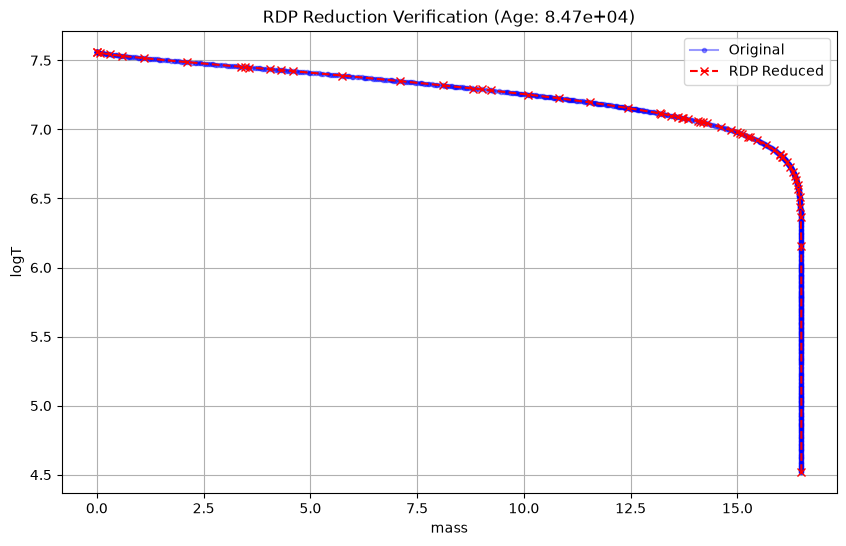

In [30]:
import matplotlib.pyplot as plt
import numpy as np
from src.preprocessing import process_simulation

# Extract the profiles directly from the RAW dataframe to keep the scale consistent
raw_splitting_features, raw_profiles = process_simulation(df)

# Select arbitrary profile index
profile_idx = 0
target_split_val_raw = raw_splitting_features[profile_idx]

# Get the original, unscaled coordinates
original_profile = raw_profiles[profile_idx][profile_features].to_numpy()

# Isolate matching reduced profile from the final output matrix
# We use np.isclose instead of '==' for safer float comparisons
mask = np.isclose(processed_df[:, -1], target_split_val_raw)
reduced_profile = processed_df[mask][:, :-1]

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(original_profile[:, 0], original_profile[:, 1], label='Original', color='blue', alpha=0.4, marker='.')

# Quick safety check to ensure points were found before plotting
if len(reduced_profile) > 0:
    plt.plot(reduced_profile[:, 0], reduced_profile[:, 1], label='RDP Reduced', color='red', marker='x', linestyle='--')
else:
    print(f"Warning: No reduced points found for age {target_split_val_raw}")

plt.title(f"RDP Reduction Verification (Age: {target_split_val_raw:.2e})")
plt.xlabel(profile_features[0])
plt.ylabel(profile_features[1])
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# check_missing_values(df_rdp)
# print(f"Data shadata/processedpe after RDP vs original shape: {df_rdp.shape} vs {df.shape}")

# df_reduced = drop_constant_columns(df_rdp)

# df_subset = df_reduced[target_features]

# df_scaled, scalers = fit_preprocess_scalers(
#     df_subset,
#     normalize=True,
#     standardize=False,
# )


In [ ]:
'''Psudocode layout for rdp algorithm'''

# import numpy as np
# import pandas as pd
# from src.config import num_profile_points, split_feature, profile_features
# from src.preprocessing import fit_preprocess_scalers, process_simulation

# def rdp_preprocess(raw_df, split_feature=split_feature, profile_features=profile_features, num_profile_points=num_profile_points):
# # Normalized minmax scaled (between 0 & 1)
# 	normalized_df = fit_preprocess_scalers(raw_df, profile_features + [split_feature], True, False)
# # stratify data into profiles based on a split feature
# 	profiles, splitting_features = process_simulation(normalized_df)
# 	#ensure the indicies from the original raw_df is preserved in the new profiles and their points

# 	# determine which profile has the minimum number of points
# 	min_points = profiles.argmin #replace with real code

# # ensure inputed num profile points is acceptible 
# 	if num_profile_points > min_points:
# 		num_profile_points = min_points

# 	for profile, feature in zip(profiles, splitting_features):
# 		while len(profiles) < num_profile_points:
# 			# implement rdp algorithm with 2 variations. One is that we will use max heap instead of epsilon to ensure that the num of points threashold is met. 2 is that it is itterative, not recursive. Implement a perpendicular distance from line function too to help the rdp. The algorithm should return a 1d array containg the indecies of points in each profile and the splitting feature value of those profiles
# 			pass
# 	# create a to numpy array that contains the data from raw_df only selecting the columns profile_features + [split_feature] and only selecting the rows that have the indecies that the above rdp algorithm found. The splitting feature should be constant not empty in this returned npy dataframe for the changing profile features. 
# 	# return this numpy array 

In [ ]:
'''Test class for RDP Algorithm'''

import unittest
import numpy as np
import pandas as pd
from unittest.mock import patch

from src.preprocessing import get_max_perpendicular_distance, iterative_rdp_max_heap, rdp_preprocess

class TestRDPAlgorithm(unittest.TestCase):
    
    def test_get_max_perpendicular_distance(self):
        points = np.array([
            [0.0, 0.0],
            [1.0, 2.0],
            [2.0, 0.5],
            [3.0, 0.0]
        ])
        
        dist, split_idx = get_max_perpendicular_distance(points, 0, 3)
        self.assertAlmostEqual(dist, 2.0, places=5)
        self.assertEqual(split_idx, 1)

    def test_get_max_perpendicular_distance_collinear(self):
        points = np.array([
            [0.0, 0.0],
            [1.0, 1.0],
            [2.0, 2.0],
            [3.0, 3.0]
        ])
        
        dist, split_idx = get_max_perpendicular_distance(points, 0, 3)
        self.assertAlmostEqual(dist, 0.0)

    def test_iterative_rdp_max_heap(self):
        points = np.array([
            [0.0, 0.0],
            [1.0, 0.1],
            [2.0, 5.0],
            [3.0, 0.2],
            [4.0, 0.0]
        ])
        original_indices = np.array([100, 101, 102, 103, 104])
        
        target_points = 3
        rdp_indices = iterative_rdp_max_heap(points, original_indices, target_points)
        
        np.testing.assert_array_equal(rdp_indices, [100, 102, 104])

    def test_iterative_rdp_target_exceeds_points(self):
        points = np.array([[0,0], [1,1], [2,0]])
        original_indices = np.array([0, 1, 2])
        rdp_indices = iterative_rdp_max_heap(points, original_indices, 10)
        
        np.testing.assert_array_equal(rdp_indices, [0, 1, 2])

    @patch('src.preprocessing.process_simulation')
    @patch('src.preprocessing.fit_preprocess_scalers')
    def test_rdp_preprocess_integration(self, mock_fit, mock_process):
        np.random.seed(42)
        raw_df = pd.DataFrame({
            'feature1': np.random.rand(10),
            'feature2': np.random.rand(10),
            'zone': [1.0]*5 + [2.0]*5
        }, index=[10, 11, 12, 13, 14, 20, 21, 22, 23, 24])

        mock_fit.return_value = (raw_df, {})
        
        profile_1 = raw_df.iloc[0:5]
        profile_2 = raw_df.iloc[5:10]
        mock_process.return_value = ([1.0, 2.0], [profile_1, profile_2])

        profile_features = ['feature1', 'feature2']
        split_feature = 'zone'
        target_points = 3
        
        output_npy = rdp_preprocess(
            raw_df=raw_df,
            split_feature=split_feature,
            profile_features=profile_features,
            num_profile_points=target_points
        )
        
        self.assertEqual(output_npy.shape, (6, 3))
        self.assertTrue(np.all(output_npy[:, 2] == np.array([1.0, 1.0, 1.0, 2.0, 2.0, 2.0])))

unittest.main(argv=['first-arg-is-ignored'], exit=False)

.....
----------------------------------------------------------------------
Ran 5 tests in 0.004s

OK


In [ ]:
stratified_data = rdp(df_visual, .05, rdp_feature)

first_age = list(stratified_data.keys())[0]

max_age_slice = max(stratified_data, key=lambda feature: len(stratified_data[feature]))
max_datapoints = len(stratified_data[max_age_slice])
min_age_slice = min(stratified_data, key=lambda feature: len(stratified_data[feature]))
min_datapoints = len(stratified_data[min_age_slice])

num_age_slices = len(stratified_data)


print(f"Time slice: {min_age_slice}")
print(f"Datapoint count: {min_datapoints}")
print(f"Time slice: {max_age_slice}")
print(f"Datapoint count: {max_datapoints}")
print(f"Total number of age slices: {num_age_slices}")

In [ ]:
# importlib.reload(sys.modules["src.train"])
from src.train import train_model

In [ ]:
metrics = train_model()

In [ ]:
epochs = range(len(metrics["train_mse"]))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(epochs, metrics["train_mse"], label="Train MSE")
ax1.plot(epochs, metrics["val_mse"], label="Validation MSE")
ax1.set_title("Reconstruction Loss (MSE)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("MSE")
ax1.legend()
ax1.grid(True, linestyle="--", alpha=0.6)

ax2.plot(epochs, metrics["train_kld"], label="Train KLD")
ax2.plot(epochs, metrics["val_kld"], label="Validation KLD")
ax2.set_title("Latent Divergence (KLD)")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("KLD")
ax2.legend()
ax2.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()